# Evaluation

## Embeddings

In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

with open("/kaggle/input/datasets/davidvista/mandarin-sounds-embeddings-zh-cn-model/pinyin_embeddings.pkl", 'rb') as f:
    embedding_map = pkl.load(f)

## Preparation

Prepare decomposed pinyin information for future categorical analysis

In [2]:
INITIALS = [
    "", "b","p","m","f","d","t","n","l","g","k","h",
    "j","q","x","zh","ch","sh","r","z","c","s"
]

FINALS = [
    "a","ai","an","ang","ao","e","ei","en","eng","er",
    "i","ia","ian","iang","iao","ie","in","ing","iong","iu",
    "o","ong","ou",
    "u","ua","uai","uan","uang","ui","un","uo",
    "v","ve","van","vn"
]

TONES = ["1","2","3","4","5"]

ZERO_INITIAL_MAP = {
    # y-series
    "yi":"i",
    "ya":"ia",
    "yao":"iao",
    "ye":"ie",
    "you":"iu",
    "yan":"ian",
    "yin":"in",
    "yang":"iang",
    "ying":"ing",
    "yong":"iong",

    "yu":"v",
    "yue":"ve",
    "yuan":"van",
    "yun":"vn",

    # w-series
    "wu":"u",
    "wa":"ua",
    "wo":"uo",
    "wai":"uai",
    "wei":"ui",
    "wan":"uan",
    "wen":"un",
    "wang":"uang",
    "weng":"ong",
}


def normalize_zero_initial(base):
    return ZERO_INITIAL_MAP.get(base, base)


def normalize_jqx(final):
    if final.startswith("u"):
        mapping = {
            "u": "v",
            "ue": "ve",
            "uan": "van",
            "un": "vn",
        }
        return mapping.get(final, final)
    return final


# init2idx = {v:i for i,v in enumerate(INITIALS)}
# final2idx = {v:i for i,v in enumerate(FINALS)}
# tone2idx = {v:i for i,v in enumerate(TONES)}

# idx2init = {i:v for v,i in init2idx.items()}
# idx2final = {i:v for v,i in final2idx.items()}
# idx2tone = {i:v for v,i in tone2idx.items()}


def decompose_pinyin(token: str):
    tone = token[-1]

    if not tone.isdigit():
        tone = "5" # neutral tone, usually has no digit
        base = token
    else:
        base = token[:-1]

    base = normalize_zero_initial(base)

    # longest-match for initials

    try:
        for ini in sorted(INITIALS, key=len, reverse=True):
            if base.startswith(ini):
                final = base[len(ini):]

                if ini in {"j","q","x"}:
                    final = normalize_jqx(final)
                
                return ini, final, tone
    except Exception:
        raise ValueError("Invalid pinyin token")

In [3]:
decompose_pinyin('ma3')

('m', 'a', '3')

In [4]:
from tqdm import tqdm

# Metadata
token_info = dict()

for pinyin_token in tqdm(list(embedding_map.keys())):
    ini, final, tone = decompose_pinyin(pinyin_token)
    token_info[pinyin_token] = {'initial': ini, 'final': final, 'tone': tone}

100%|██████████| 1102/1102 [00:00<00:00, 205802.71it/s]


In [5]:
token_info['ma3']

{'initial': 'm', 'final': 'a', 'tone': '3'}

Cosine similarity will be used for measuring closeness in the space:

In [6]:
import numpy as np
from itertools import combinations
from scipy.stats import sem, t

def cosine_similarity(a, b):
    """Cosine similarity between two 1D numpy arrays."""
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot / (norm_a * norm_b)

def intra_group_similarity(group_tokens, emb_map, confidence=0.95):
    """
    Pairwise cosine similarities within a group.
    Returns: dict with mean, std, confidence interval, count.
    """
    tokens = [t for t in group_tokens if t in emb_map]
    if len(tokens) < 2:
        return {'mean': None, 'std': None, 'ci_lower': None, 'ci_upper': None, 'count': 0}
    
    sims = []
    for t1, t2 in combinations(tokens, 2):
        sims.append(cosine_similarity(emb_map[t1], emb_map[t2]))
    sims = np.array(sims)
    mean = np.mean(sims)
    std = np.std(sims, ddof=1)
    n = len(sims)
    se = sem(sims) if n > 1 else 0.0
    ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0
    return {
        'sims': sims,
        'mean': mean, 'std': std,
        'ci_lower': mean - ci, 'ci_upper': mean + ci,
        'count': n
    }

def inter_group_similarity(group_a, group_b, emb_map, confidence=0.95):
    """
    Pairwise cosine similarities between two groups.
    """
    tokens_a = [t for t in group_a if t in emb_map]
    tokens_b = [t for t in group_b if t in emb_map]
    if not tokens_a or not tokens_b:
        return {'mean': None, 'std': None, 'ci_lower': None, 'ci_upper': None, 'count': 0}
    
    sims = []
    for t1 in tokens_a:
        for t2 in tokens_b:
            sims.append(cosine_similarity(emb_map[t1], emb_map[t2]))
    sims = np.array(sims)
    mean = np.mean(sims)
    std = np.std(sims, ddof=1)
    n = len(sims)
    se = sem(sims) if n > 1 else 0.0
    ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0
    return {
        'mean': mean, 'std': std,
        'ci_lower': mean - ci, 'ci_upper': mean + ci,
        'count': n
    }

## Stratification

In [7]:
from itertools import combinations

tokens = list(token_info.keys())

same_syllable_group = []
same_initial_group = []
same_final_group = []
same_tone_group = []
none_group = []


for (token1, token2) in combinations(tokens, r=2):

    initial_1, final_1, tone_1 = token_info[token1].values()
    initial_2, final_2, tone_2 = token_info[token2].values()

    # Same syllable group
    if initial_1 == initial_2 and final_1 == final_2:
        same_syllable_group.append((token1, token2))
        continue
    # Same initial group
    if initial_1 == initial_2:
        same_initial_group.append((token1, token2))
        continue
    # Same final group
    if final_1 == final_2:
        same_final_group.append((token1, token2))
        continue
    # Same tone group
    if tone_1 == tone_2:
        same_tone_group.append((token1, token2))
        continue

    none_group.append((token1, token2))

In [8]:
phonetic_groups = [same_syllable_group, same_initial_group, same_final_group, same_tone_group, none_group]

In [9]:
group_sizes = pd.Series({
    'Same syllable': len(same_syllable_group),
    'Same initial': len(same_initial_group),
    'Same final': len(same_final_group),
    'Same tone': len(same_tone_group),
    'None': len(none_group),
})

In [10]:
group_sizes

Same syllable      1205
Same initial      28647
Same final        20781
Same tone        136401
None             419617
dtype: int64

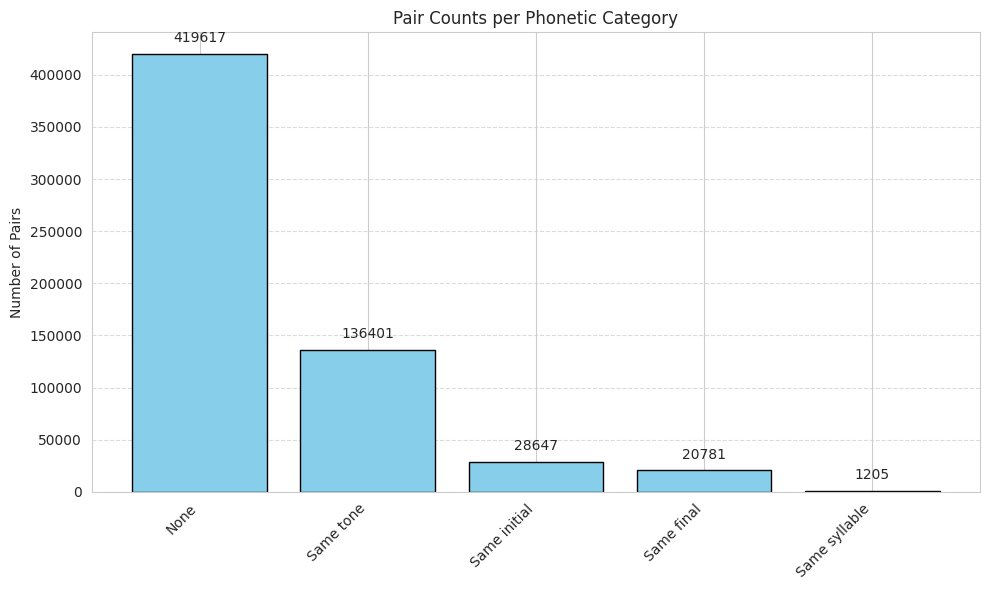

In [11]:
# Sort for better readability (optional)
group_sizes = group_sizes.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.bar(group_sizes.index, group_sizes.values, color='skyblue', edgecolor='black')

# Add count labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02 * max(group_sizes.values),
             f'{int(height)}', ha='center', va='bottom', fontsize=10)

plt.ylabel('Number of Pairs')
plt.title('Pair Counts per Phonetic Category')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Baseline: Randomized Similarity

In [12]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations
K = 1000 # sample size (number of pairs from each group)

baseline_scores = []

for _ in tqdm(range(N)):
    total = 0
    for group in phonetic_groups:
        for (token1, token2) in random.sample(group, K):
            total += cosine_similarity(embedding_map[token1], embedding_map[token2])
    baseline_score = total / (K * len(phonetic_groups))
    baseline_scores.append(baseline_score)

100%|██████████| 1000/1000 [00:56<00:00, 17.78it/s]


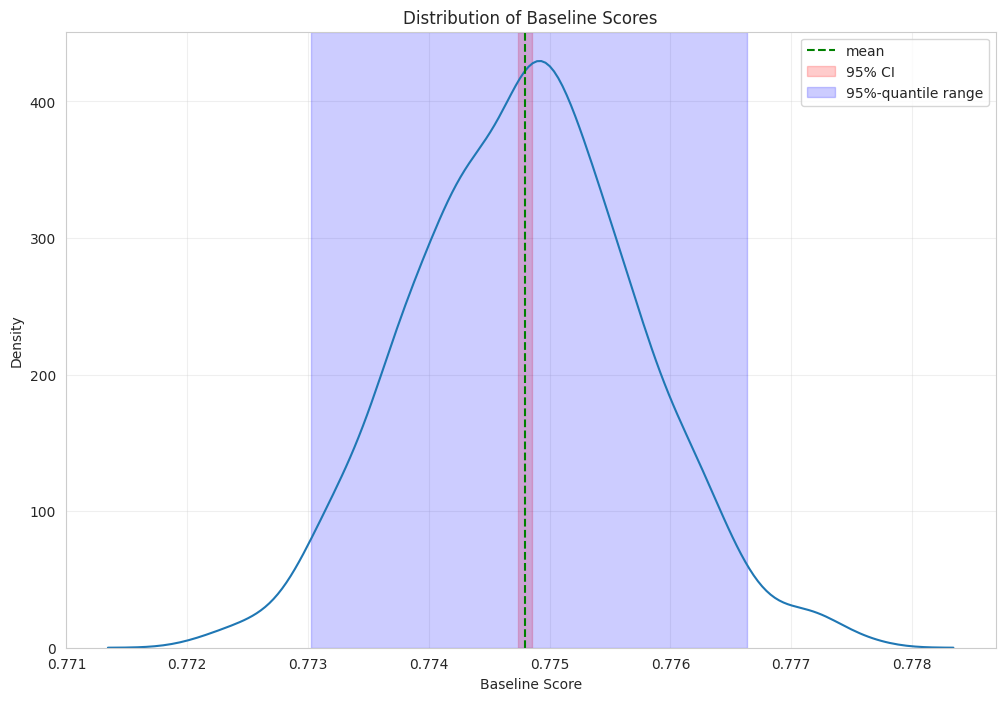

In [13]:
from scipy.stats import sem, t

plt.figure(figsize=(12, 8))
plt.title("Distribution of Baseline Scores")

plt.xlabel("Baseline Score")

sns.kdeplot(baseline_scores)

n = len(baseline_scores)
confidence = 0.95

mean = np.mean(baseline_scores)
se = sem(baseline_scores) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(np.quantile(baseline_scores, 0.025), np.quantile(baseline_scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [14]:
baseline_mean = np.mean(baseline_scores)

baseline_mean

np.float32(0.7747996)

## None Common

In [15]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations

total = 0
for (token1, token2) in none_group:
    total += cosine_similarity(embedding_map[token1], embedding_map[token2])

none_score = total / len(none_group)

none_score

np.float32(0.70251614)

In [16]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations
K = 1000 # sample size (number of pairs from a group)

none_scores = []

for _ in tqdm(range(N)):
    total = 0
    for (token1, token2) in random.choices(none_group, k=K):
        total += cosine_similarity(embedding_map[token1], embedding_map[token2])
    none_score = total / K
    none_scores.append(none_score)

100%|██████████| 1000/1000 [00:10<00:00, 94.32it/s]


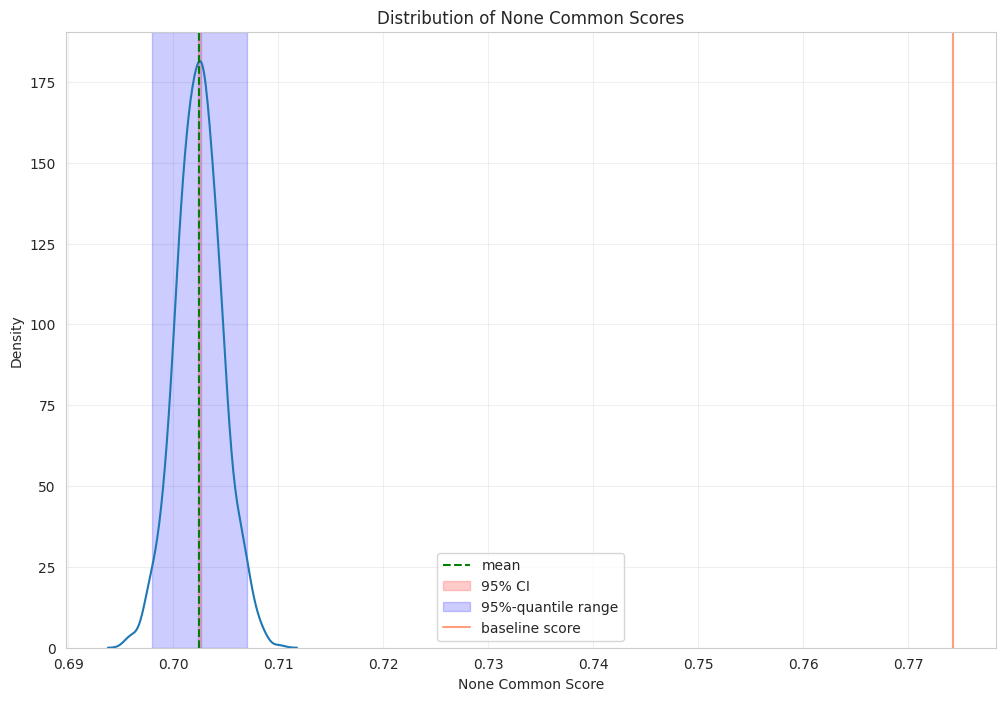

In [17]:
from scipy.stats import sem, t

plt.figure(figsize=(12, 8))
plt.title("Distribution of None Common Scores")

plt.xlabel("None Common Score")

sns.kdeplot(none_scores)

n = len(none_scores)
confidence = 0.95

mean = np.mean(none_scores)
se = sem(none_scores) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(np.quantile(none_scores, 0.025), np.quantile(none_scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')

plt.axvline(baseline_score, color='lightsalmon', label='baseline score')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Same Syllable

In [18]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations

total = 0
for (token1, token2) in same_syllable_group:
    total += cosine_similarity(embedding_map[token1], embedding_map[token2])

same_syllable_score = total / len(same_syllable_group)

same_syllable_score

np.float32(0.86598444)

In [19]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations
K = 1000 # sample size (number of pairs from a group)

same_syllable_scores = []

for _ in tqdm(range(N)):
    total = 0
    for (token1, token2) in random.choices(same_syllable_group, k=K):
        total += cosine_similarity(embedding_map[token1], embedding_map[token2])
    same_syllable_score = total / K
    same_syllable_scores.append(same_syllable_score)

100%|██████████| 1000/1000 [00:10<00:00, 93.32it/s]


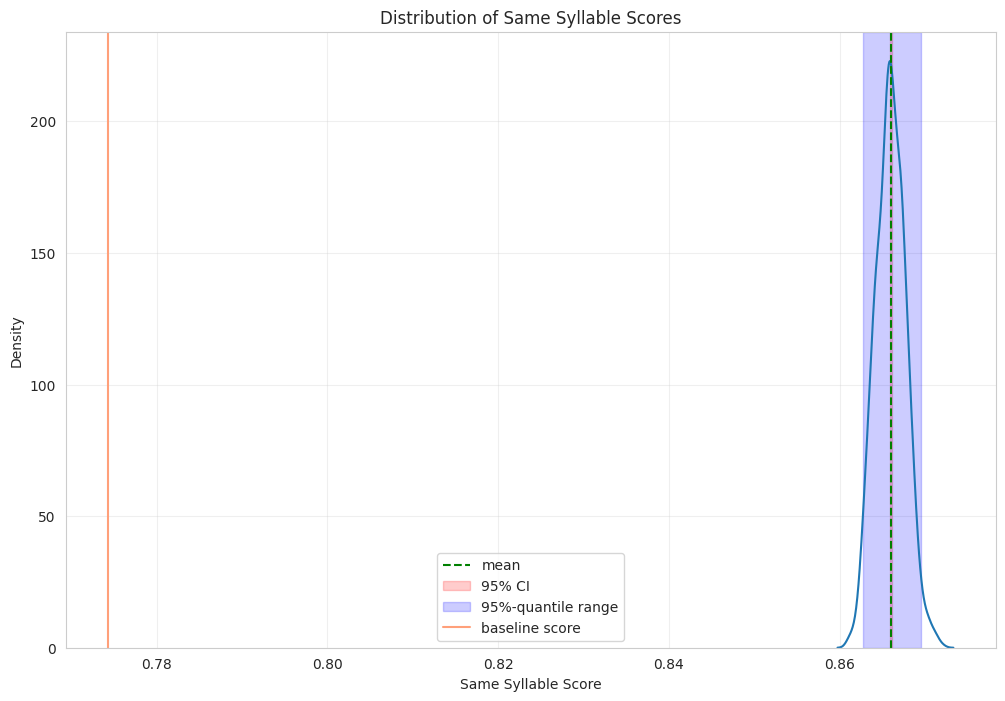

In [20]:
from scipy.stats import sem, t

plt.figure(figsize=(12, 8))
plt.title("Distribution of Same Syllable Scores")

plt.xlabel("Same Syllable Score")

sns.kdeplot(same_syllable_scores)

n = len(same_syllable_scores)
confidence = 0.95

mean = np.mean(same_syllable_scores)
se = sem(same_syllable_scores) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(np.quantile(same_syllable_scores, 0.025), np.quantile(same_syllable_scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')

plt.axvline(baseline_score, color='lightsalmon', label='baseline score')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Same Initial

In [21]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations

total = 0
for (token1, token2) in same_initial_group:
    total += cosine_similarity(embedding_map[token1], embedding_map[token2])

same_initial_score = total / len(same_initial_group)

same_initial_score

np.float32(0.75709325)

In [22]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations
K = 1000 # sample size (number of pairs from a group)

same_initial_scores = []

for _ in tqdm(range(N)):
    total = 0
    for (token1, token2) in random.choices(same_initial_group, k=K):
        total += cosine_similarity(embedding_map[token1], embedding_map[token2])
    same_initial_score = total / K
    same_initial_scores.append(same_initial_score)

100%|██████████| 1000/1000 [00:10<00:00, 91.96it/s]


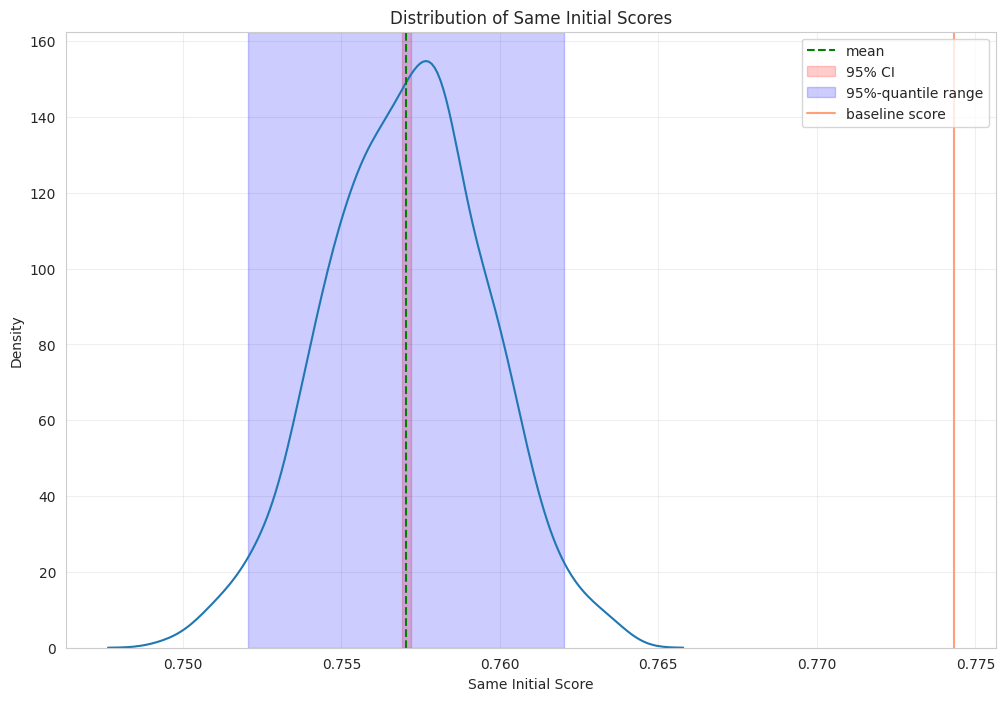

In [23]:
from scipy.stats import sem, t

plt.figure(figsize=(12, 8))
plt.title("Distribution of Same Initial Scores")

plt.xlabel("Same Initial Score")

sns.kdeplot(same_initial_scores)

n = len(same_initial_scores)
confidence = 0.95

mean = np.mean(same_initial_scores)
se = sem(same_initial_scores) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(np.quantile(same_initial_scores, 0.025), np.quantile(same_initial_scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')

plt.axvline(baseline_score, color='lightsalmon', label='baseline score')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Same Final

In [24]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations

total = 0
for (token1, token2) in same_final_group:
    total += cosine_similarity(embedding_map[token1], embedding_map[token2])

same_final_score = total / len(same_final_group)

same_final_score

np.float32(0.8038875)

In [25]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations
K = 1000 # sample size (number of pairs from a group)

same_final_scores = []

for _ in tqdm(range(N)):
    total = 0
    for (token1, token2) in random.choices(same_final_group, k=K):
        total += cosine_similarity(embedding_map[token1], embedding_map[token2])
    same_final_score = total / K
    same_final_scores.append(same_final_score)

100%|██████████| 1000/1000 [00:10<00:00, 94.80it/s]


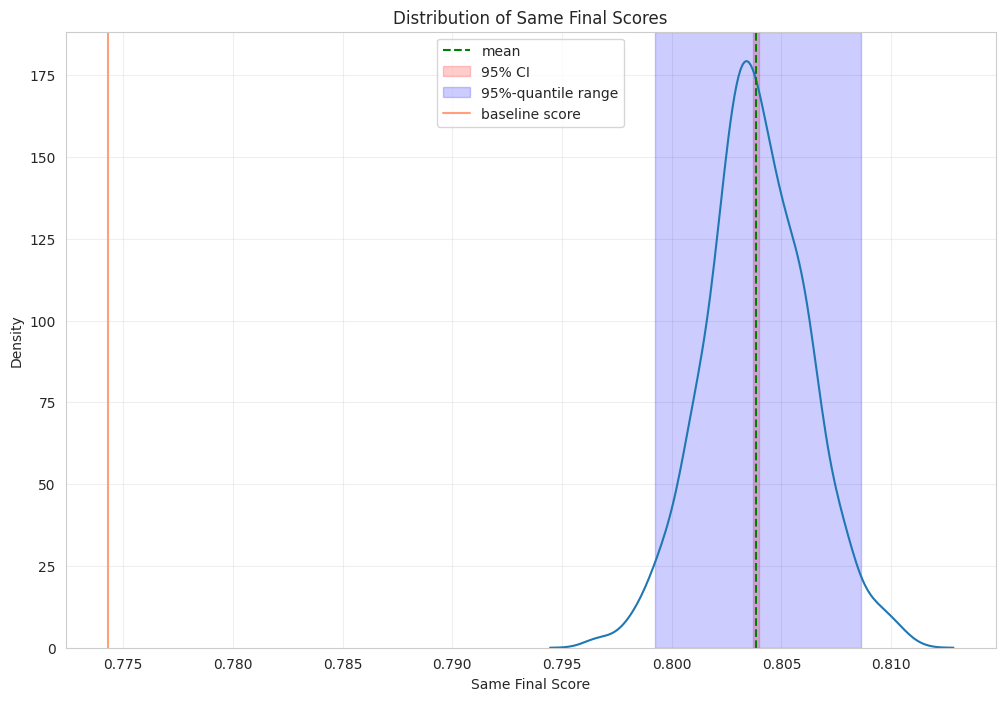

In [26]:
from scipy.stats import sem, t

plt.figure(figsize=(12, 8))
plt.title("Distribution of Same Final Scores")

plt.xlabel("Same Final Score")

sns.kdeplot(same_final_scores)

n = len(same_final_scores)
confidence = 0.95

mean = np.mean(same_final_scores)
se = sem(same_final_scores) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(np.quantile(same_final_scores, 0.025), np.quantile(same_final_scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')

plt.axvline(baseline_score, color='lightsalmon', label='baseline score')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Same Tone

In [27]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations

total = 0
for (token1, token2) in same_tone_group:
    total += cosine_similarity(embedding_map[token1], embedding_map[token2])

same_tone_score = total / len(same_tone_group)

same_tone_score

np.float32(0.7445638)

In [28]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations
K = 1000 # sample size (number of pairs from a group)

same_tone_scores = []

for _ in tqdm(range(N)):
    total = 0
    for (token1, token2) in random.choices(same_tone_group, k=K):
        total += cosine_similarity(embedding_map[token1], embedding_map[token2])
    same_tone_score = total / K
    same_tone_scores.append(same_tone_score)

100%|██████████| 1000/1000 [00:10<00:00, 92.88it/s]


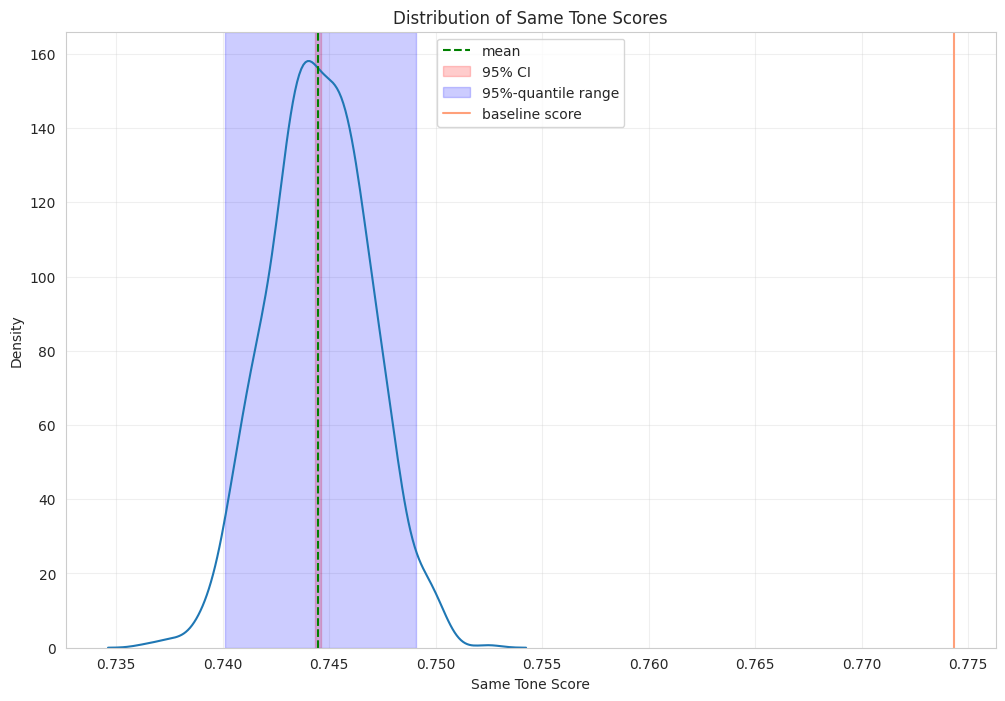

In [29]:
from scipy.stats import sem, t

plt.figure(figsize=(12, 8))
plt.title("Distribution of Same Tone Scores")

plt.xlabel("Same Tone Score")

sns.kdeplot(same_tone_scores)

n = len(same_tone_scores)
confidence = 0.95

mean = np.mean(same_tone_scores)
se = sem(same_tone_scores) if n > 1 else 0.0
ci = t.ppf((1 + confidence)/2, n-1) * se if n > 1 else 0.0

plt.axvline(mean, linestyle='--', color='green', label='mean')
plt.axvspan(mean-ci, mean+ci, alpha=0.2, color='red', label='95% CI')
plt.axvspan(np.quantile(same_tone_scores, 0.025), np.quantile(same_tone_scores, 0.975), alpha=0.2, color='blue', label='95%-quantile range')

plt.axvline(baseline_score, color='lightsalmon', label='baseline score')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Tone Grouping

In [30]:
from collections import defaultdict

tone_groups = defaultdict(list)

for (token1, token2) in same_tone_group:
    tone = token_info[token1]['tone']
    tone_groups[tone].append((token1, token2))

### Tone 1

In [31]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations

total_tone_scores = defaultdict(int)

for tone, tone_group in tone_groups.items():
    total = 0
    for (token1, token2) in tone_group:
        total += cosine_similarity(embedding_map[token1], embedding_map[token2])

    tone_score = total / len(tone_group)
    
    total_tone_scores[tone] = tone_score

In [32]:
total_tone_scores

defaultdict(int,
            {'3': np.float32(0.71335834),
             '1': np.float32(0.77000314),
             '4': np.float32(0.7648233),
             '2': np.float32(0.70863116),
             '5': np.float32(0.78149396)})

In [33]:
import random
from tqdm import tqdm

random.seed(0)

N = 1000 # number of sampling iterations
K = 1000 # sample size (number of pairs from a group)

mean_tone_scores = defaultdict(int)

for tone, tone_group in tone_groups.items():
    tone_scores = []

    print(f"Tone {tone}")
    for _ in tqdm(range(N)):
        total = 0
        for (token1, token2) in random.choices(tone_group, k=min(K, len(tone_group))):
            total += cosine_similarity(embedding_map[token1], embedding_map[token2])
        tone_score = total / min(K, len(tone_group))
        tone_scores.append(tone_score)

    mean_tone_scores[tone] = tone_scores

Tone 3


100%|██████████| 1000/1000 [00:10<00:00, 99.46it/s]


Tone 1


100%|██████████| 1000/1000 [00:10<00:00, 99.79it/s]


Tone 4


100%|██████████| 1000/1000 [00:10<00:00, 99.16it/s] 


Tone 2


100%|██████████| 1000/1000 [00:09<00:00, 100.98it/s]


Tone 5


100%|██████████| 1000/1000 [00:00<00:00, 1284.95it/s]


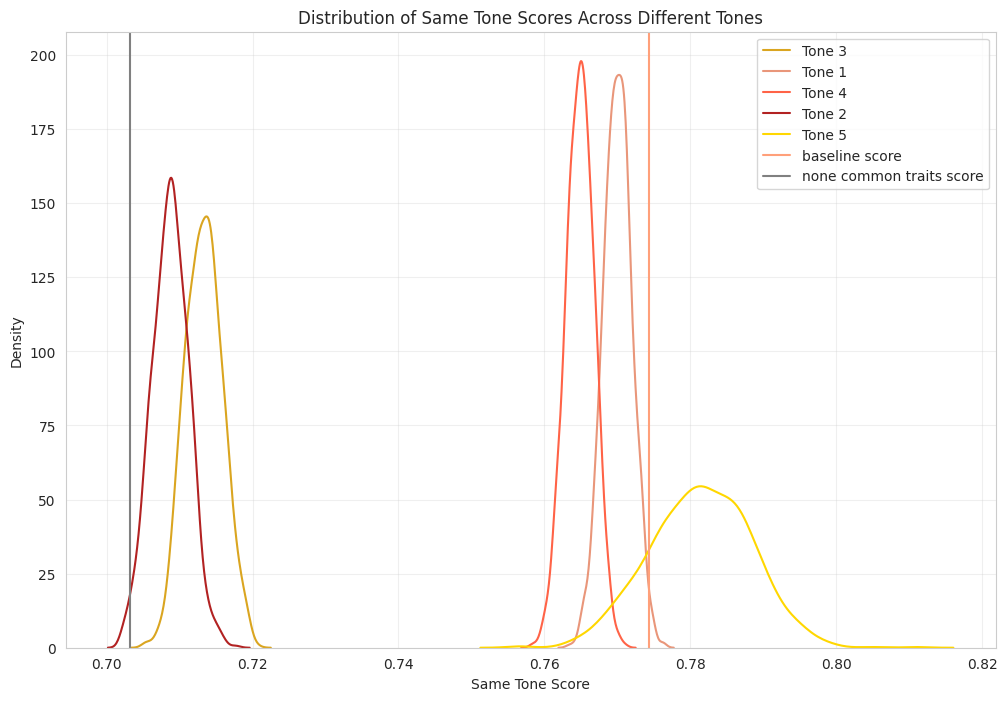

In [34]:
from scipy.stats import sem, t

plt.figure(figsize=(12, 8))
plt.title("Distribution of Same Tone Scores Across Different Tones")

plt.xlabel("Same Tone Score")

# Define a color palette for the groups
colors = ['goldenrod', 'darksalmon', 'tomato', 'firebrick', 'gold']

for i, (tone, mean_scores) in enumerate(mean_tone_scores.items()):
    sns.kdeplot(mean_scores, color=colors[i % len(colors)], label=f'Tone {tone}')
    
plt.axvline(baseline_score, color='lightsalmon', label='baseline score')
plt.axvline(none_score, color='grey', label='none common traits score')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Groups Overall

Same syllable score: 0.8661263585090637
Same final score: 0.8007218837738037
Baseline score: 0.7743098139762878
Same initial score: 0.7603773474693298
Same tone score: 0.7483205795288086
None common score: 0.7032546997070312


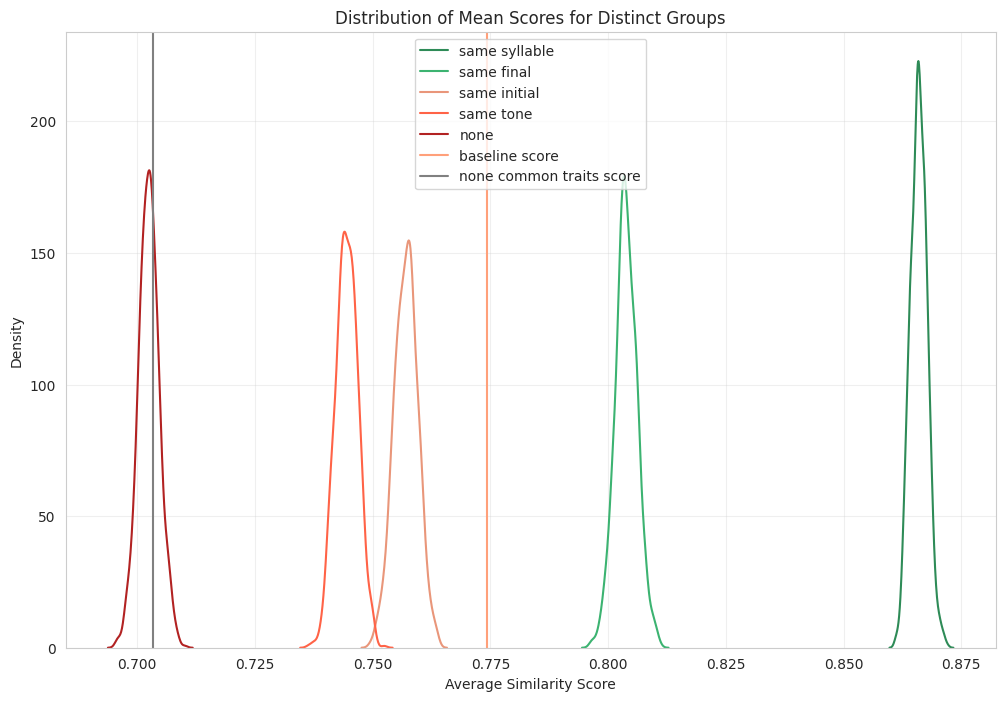

In [35]:
from scipy.stats import sem, t


print(f'Same syllable score: {same_syllable_score}')
print(f'Same final score: {same_final_score}')
print(f'Baseline score: {baseline_score}')
print(f'Same initial score: {same_initial_score}')
print(f'Same tone score: {same_tone_score}')
print(f'None common score: {none_score}')

plt.figure(figsize=(12, 8))
plt.title("Distribution of Mean Scores for Distinct Groups")

plt.xlabel("Average Similarity Score")

sns.kdeplot(same_syllable_scores, color='seagreen', label='same syllable')
sns.kdeplot(same_final_scores, color='mediumseagreen', label='same final')
sns.kdeplot(same_initial_scores, color='darksalmon', label='same initial')
sns.kdeplot(same_tone_scores, color='tomato', label='same tone')
sns.kdeplot(none_scores, color='firebrick', label='none')

plt.axvline(baseline_score, color='lightsalmon', label='baseline score')
plt.axvline(none_score, color='grey', label='none common traits score')

plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Initial Groups

In [36]:
from collections import defaultdict

# Initial groups (predefined categories)
initial_categories = {
    'labials': {'b','p','m','f'},
    'alveolars': {'d','t','n','l'},
    'dentals': {'z','c','s'},
    'retroflex': {'zh','ch','sh','r'},
    'palatals': {'j','q','x'},
    'velars': {'g','k','h'},
    'null_init': {''}   # tokens with no initial (e.g., 'a1', 'o2')
}

# Build initial group token lists
initial_groups = {cat: [] for cat in initial_categories}
for token, info in token_info.items():
    init = info['initial']
    for cat, init_set in initial_categories.items():
        if init in init_set:
            initial_groups[cat].append(token)
            break


# Print sizes for verification
print("Initial group sizes:")
for cat, tokens in initial_groups.items():
    print(f"  {cat}: {len(tokens)}")

Initial group sizes:
  labials: 180
  alveolars: 230
  dentals: 113
  retroflex: 192
  palatals: 134
  velars: 147
  null_init: 106


In [37]:
import random
import numpy as np
from tqdm import tqdm

def intra_group_similarity(group, emb_map, n_pairs=1000, n_iterations=1000):
    """
    Compute cosine similarity for random pairs within a group.
    Performs n_iterations bootstrap samples, each with n_pairs pairs.
    Returns:
        means: list of mean similarities per iteration
        overall_mean: average of means
        ci_lower, ci_upper: 95% confidence interval of the means
    """
    tokens = list(group)
    if len(tokens) < 2:
        return [], np.nan, np.nan, np.nan
    
    means = []
    for _ in tqdm(range(n_iterations)):
        sims = []
        for _ in range(n_pairs):
            t1, t2 = random.sample(tokens, 2)
            sims.append(cosine_similarity(emb_map[t1], emb_map[t2]))
        means.append(np.mean(sims))
    
    overall_mean = np.mean(means)
    ci_lower = np.percentile(means, 2.5)
    ci_upper = np.percentile(means, 97.5)
    return means, overall_mean, ci_lower, ci_upper

# Run for each initial group
intra_results = {}
intra_means = {}  # store the list of means for plotting if needed

for name, group in initial_groups.items():
    means, overall_mean, ci_lower, ci_upper = intra_group_similarity(group, embedding_map)
    intra_results[name] = {
        'overall_mean': overall_mean,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    }
    intra_means[name] = means
    print(f"{name}: mean = {overall_mean:.4f}, 95% CI = [{ci_lower:.4f}, {ci_upper:.4f}]")

100%|██████████| 1000/1000 [00:11<00:00, 84.67it/s]


labials: mean = 0.7402, 95% CI = [0.7353, 0.7452]


100%|██████████| 1000/1000 [00:11<00:00, 85.92it/s]


alveolars: mean = 0.7382, 95% CI = [0.7336, 0.7433]


100%|██████████| 1000/1000 [00:11<00:00, 87.20it/s]


...

palatals: mean = 0.7120, 95% CI = [0.7069, 0.7174]


100%|██████████| 1000/1000 [00:11<00:00, 85.68it/s]


velars: mean = 0.7340, 95% CI = [0.7289, 0.7392]


100%|██████████| 1000/1000 [00:11<00:00, 86.67it/s]

null_init: mean = 0.7532, 95% CI = [0.7475, 0.7589]


In [38]:
intra_results

{'labials': {'overall_mean': np.float32(0.7402325),
  'ci_lower': np.float32(0.7353085),
  'ci_upper': np.float32(0.7452351)},
 'alveolars': {'overall_mean': np.float32(0.7382407),
  'ci_lower': np.float32(0.7335927),
  'ci_upper': np.float32(0.7433487)},
 'dentals': {'overall_mean': np.float32(0.75060225),
  'ci_lower': np.float32(0.7465726),
  'ci_upper': np.float32(0.75478923)},
 'retroflex': {'overall_mean': np.float32(0.7410288),
  'ci_lower': np.float32(0.7365412),
  'ci_upper': np.float32(0.74576163)},
 'palatals': {'overall_mean': np.float32(0.71199864),
  'ci_lower': np.float32(0.70687467),
  'ci_upper': np.float32(0.7173987)},
 'velars': {'overall_mean': np.float32(0.73400086),
  'ci_lower': np.float32(0.7289414),
  'ci_upper': np.float32(0.7392004)},
 'null_init': {'overall_mean': np.float32(0.75316966),
  'ci_lower': np.float32(0.7475297),
  'ci_upper': np.float32(0.7588724)}}

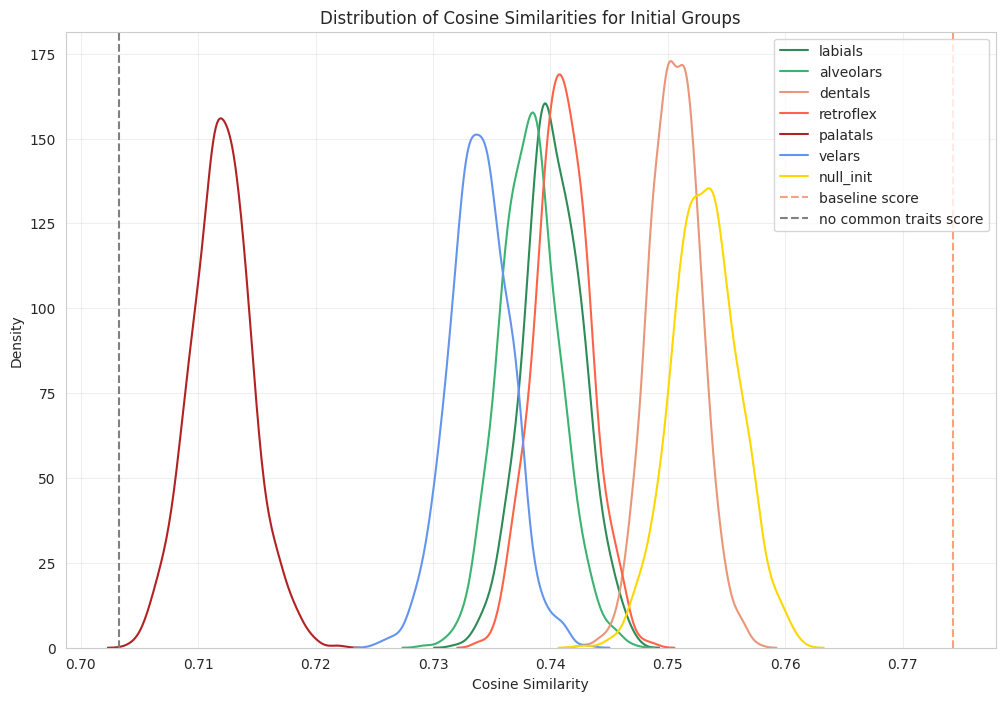

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 8))
plt.title("Distribution of Cosine Similarities for Initial Groups")

# Define a color palette for the groups
colors = ['seagreen', 'mediumseagreen', 'darksalmon', 'tomato', 'firebrick', 'cornflowerblue', 'gold']

for i, (group_name, scores) in enumerate(intra_means.items()):
    sns.kdeplot(scores, color=colors[i % len(colors)], label=group_name)

# Add baseline line (e.g., from your bootstrap)
plt.axvline(baseline_score, color='lightsalmon', linestyle='--', label='baseline score')
plt.axvline(none_score, color='grey', linestyle='--', label='no common traits score')

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [40]:
def inter_group_similarity(group_a, group_b, emb_map, n_pairs=10000):
    pairs = []
    tokens_a = list(group_a)
    tokens_b = list(group_b)
    if not tokens_a or not tokens_b:
        return np.nan
    for _ in range(n_pairs):
        t1 = random.choice(tokens_a)
        t2 = random.choice(tokens_b)
        sim = cosine_similarity(emb_map[t1], emb_map[t2])
        pairs.append(sim)
    return np.mean(pairs), np.std(pairs)

inter_results = {}
group_names = list(initial_groups.keys())
for i in range(len(group_names)):
    for j in range(i+1, len(group_names)):
        name = f"{group_names[i]} vs {group_names[j]}"
        mean, std = inter_group_similarity(initial_groups[group_names[i]], 
                                           initial_groups[group_names[j]], 
                                           embedding_map)
        inter_results[name] = (mean, std)

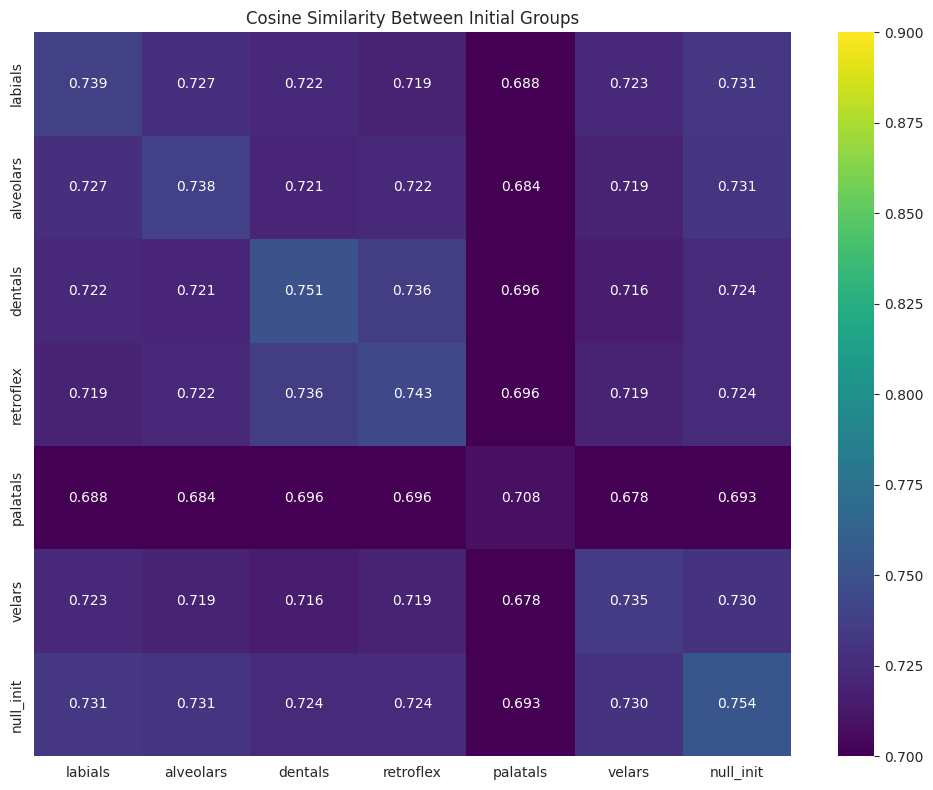

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build similarity matrix
n = len(group_names)
sim_matrix = np.zeros((n, n))
for i, name_i in enumerate(group_names):
    for j, name_j in enumerate(group_names):
        if i == j:
            sim_matrix[i, j] = intra_means[name_i][0]
        else:
            key = f"{name_i} vs {name_j}" if i < j else f"{name_j} vs {name_i}"
            sim_matrix[i, j] = inter_results.get(key, (0,))[0]

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, annot=True, fmt='.3f', xticklabels=group_names, yticklabels=group_names, 
            cmap='viridis', vmin=0.7, vmax=0.9)
plt.title('Cosine Similarity Between Initial Groups')
plt.tight_layout()
plt.show()

### Dimensionality Reduction

In [42]:
import numpy as np
import pandas as pd

tokens = list(embedding_map.keys())
X = np.stack([embedding_map[t] for t in tokens])   # shape (n_samples, n_features)

print(f"Feature matrix shape: {X.shape}")

Feature matrix shape: (1102, 1024)


In [43]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance ratio
explained_var = pca.explained_variance_ratio_
cumulative = np.cumsum(explained_var)

print("Explained variance ratio (first 10):")
for i, ev in enumerate(explained_var[:10]):
    print(f"PC{i+1}: {ev:.4f}")

# Number of components to reach 90% variance
n_90 = np.argmax(cumulative >= 0.90) + 1
print(f"\nNumber of components to explain 90% variance: {n_90}")
print(f"Cumulative variance at {n_90} components: {cumulative[n_90-1]:.4f}")

Explained variance ratio (first 10):
PC1: 0.0863
PC2: 0.0698
PC3: 0.0594
PC4: 0.0553
PC5: 0.0488
PC6: 0.0384
PC7: 0.0334
PC8: 0.0292
PC9: 0.0290
PC10: 0.0266

Number of components to explain 90% variance: 91
Cumulative variance at 91 components: 0.9001


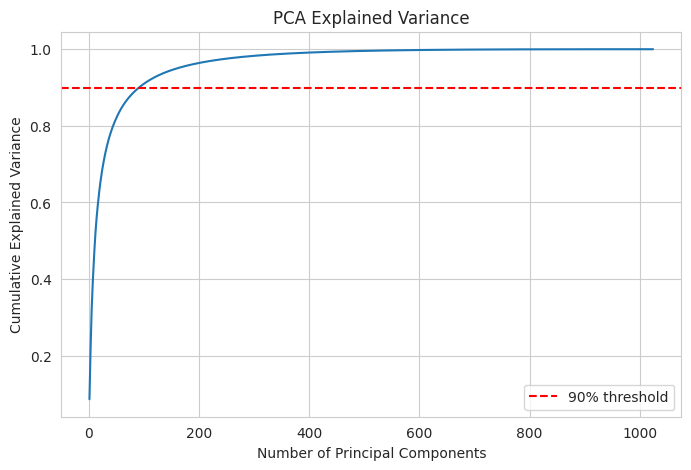

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative)+1), cumulative, linestyle='-')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')
plt.grid(True)
plt.legend()
plt.show()

In [45]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Take first 2 principal components
X_pca_2d = X_pca[:, :2]


df = pd.DataFrame({
    'token': tokens,
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'initial': [token_info[t]['initial'] for t in tokens],
    'final': [token_info[t]['final'] for t in tokens],
    'tone': [token_info[t]['tone'] for t in tokens]
})

# Map tone numbers to labels for legend
tone_labels = {'1': 'Tone 1', '2': 'Tone 2', '3': 'Tone 3', '4': 'Tone 4', '5': 'Neutral'}
df['tone_label'] = df['tone'].map(tone_labels)

# Encode categorical columns to numeric codes
encoders = {}
for col in ['initial', 'final', 'tone_label']:
    le = LabelEncoder()
    df[col + '_code'] = le.fit_transform(df[col])
    encoders[col] = le

# Print mapping for reference
for col, le in encoders.items():
    print(f"\n{col} mapping:")
    for i, name in enumerate(le.classes_):
        print(f"  {i}: {name}")


initial mapping:
  0: 
  1: b
  2: c
  3: ch
  4: d
  5: f
  6: g
  7: h
  8: j
  9: k
  10: l
  11: m
  12: n
  13: p
  14: q
  15: r
  16: s
  17: sh
  18: t
  19: x
  20: z
  21: zh

final mapping:
  0: a
  1: ai
  2: an
  3: ang
  4: ao
  5: e
  6: ei
  7: en
  8: eng
  9: er
  10: i
  11: ia
  12: ian
  13: iang
  14: iao
  15: ie
  16: in
  17: ing
  18: iong
  19: iu
  20: o
  21: ong
  22: ou
  23: u
  24: ua
  25: uai
  26: uan
  27: uang
  28: ui
  29: un
  30: uo
  31: v
  32: van
  33: ve
  34: vn

tone_label mapping:
  0: Neutral
  1: Tone 1
  2: Tone 2
  3: Tone 3
  4: Tone 4


In [46]:
import plotly.graph_objects as go
import plotly.express as px

# Get unique values and create discrete colorscales
def get_discrete_colorscale(categories):
    """Return a colorscale that maps integer codes to distinct colors."""
    n = len(categories)
    # Use Plotly qualitative colors
    colors = px.colors.qualitative.Plotly[:n]
    # Build colorscale: each category gets a solid color block
    step = 1.0 / n
    colorscale = []
    for i, col in enumerate(colors):
        # Start of block
        colorscale.append((i * step, col))
        # End of block (same color)
        colorscale.append(((i+1) * step, col))

    return colorscale

# Precompute colorscales for each column
color_scales = {}
for col in ['initial', 'final', 'tone_label']:
    categories = encoders[col].classes_
    color_scales[col] = get_discrete_colorscale(categories)

# Default column for initial coloring
default_col = 'initial'
df_col_code = default_col + '_code'
color_scale = color_scales[default_col]

# Create figure
fig = go.Figure()

# Add trace with default coloring
fig.add_trace(go.Scattergl(
    x=df['PC1'],
    y=df['PC2'],
    mode='markers',
    marker=dict(
        color=df[df_col_code],
        colorscale=color_scale,
        cmin=0,
        cmax=len(encoders[default_col].classes_) - 1,
        size=5,
        opacity=0.6,
        showscale=True,
        colorbar=dict(title=default_col.capitalize())
    ),
    text=df['token'],
    hovertemplate='<b>%{text}</b><br>Initial: %{customdata[0]}<br>Final: %{customdata[1]}<br>Tone: %{customdata[2]}<extra></extra>',
    customdata=df[['initial','final','tone_label']].values
))

fig.update_layout(
    title='PCA of Acoustic Embeddings (First 2 Components)',
    xaxis_title='PC1',
    yaxis_title='PC2',
    width=1000,
    height=700,
    hovermode='closest'
)

# Dropdown buttons
buttons = []
for col in ['initial', 'final', 'tone_label']:
    col_code = col + '_code'
    buttons.append(
        dict(
            label=col.capitalize(),
            method='restyle',
            args=[
                {'marker.color': [df[col_code]],
                 'marker.colorscale': [color_scales[col]],
                 'marker.cmax': [len(encoders[col].classes_) - 1],
                 'marker.colorbar.title': [col.capitalize()]}
            ]
        )
    )

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.1,
        xanchor='left',
        yanchor='top'
    )]
)

fig.show()

In [47]:
!pip install umap-learn   # if not already installed

import umap
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
import plotly.graph_objects as go
import plotly.express as px

2026-04-10 15:36:32.672949: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775835392.977107      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775835393.065898      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775835393.765409      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775835393.765532      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775835393.765536      17 computation_placer.cc:177] computation placer alr

In [48]:
tokens = list(embedding_map.keys())
X = np.stack([embedding_map[t] for t in tokens])   # shape (n_samples, n_features)

# Standardization can help UMAP, but UMAP is robust.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Feature matrix shape: {X_scaled.shape}")

Feature matrix shape: (1102, 1024)


In [49]:
# Parameters
n_neighbors = 15
min_dist = 0.1
n_components = 2
random_state = 42

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    min_dist=min_dist,
    n_components=n_components,
    random_state=random_state,
    verbose=True
)

X_umap = reducer.fit_transform(X_scaled)
print(f"UMAP embedding shape: {X_umap.shape}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP(n_jobs=1, random_state=42, verbose=True)
Fri Apr 10 15:37:12 2026 Construct fuzzy simplicial set
Fri Apr 10 15:37:14 2026 Finding Nearest Neighbors
Fri Apr 10 15:37:17 2026 Finished Nearest Neighbor Search
Fri Apr 10 15:37:20 2026 Construct embedding


Epochs completed:   0%|            0/500 [00:00]

	completed  0  /  500 epochs
	completed  50  /  500 epochs
	completed  100  /  500 epochs
	completed  150  /  500 epochs
	completed  200  /  500 epochs
	completed  250  /  500 epochs
	completed  300  /  500 epochs
	completed  350  /  500 epochs
	completed  400  /  500 epochs
	completed  450  /  500 epochs
Fri Apr 10 15:37:23 2026 Finished embedding
UMAP embedding shape: (1102, 2)


In [50]:
df = pd.DataFrame({
    'token': tokens,
    'UMAP1': X_umap[:, 0],
    'UMAP2': X_umap[:, 1],
    'initial': [token_info[t]['initial'] for t in tokens],
    'final': [token_info[t]['final'] for t in tokens],
    'tone': [token_info[t]['tone'] for t in tokens]
})

# Map tone numbers to labels for legend
tone_labels = {'5': 'Neutral', '1': 'Tone 1', '2': 'Tone 2', '3': 'Tone 3', '4': 'Tone 4'}
df['tone_label'] = df['tone'].map(tone_labels)

# Encode categorical columns to numeric codes for plotting
encoders = {}
for col in ['initial', 'final', 'tone_label']:
    le = LabelEncoder()
    df[col + '_code'] = le.fit_transform(df[col])
    encoders[col] = le

# Print category mapping for reference
for col, le in encoders.items():
    print(f"\n{col} mapping:")
    for i, name in enumerate(le.classes_):
        print(f"  {i}: {name}")


initial mapping:
  0: 
  1: b
  2: c
  3: ch
  4: d
  5: f
  6: g
  7: h
  8: j
  9: k
  10: l
  11: m
  12: n
  13: p
  14: q
  15: r
  16: s
  17: sh
  18: t
  19: x
  20: z
  21: zh

final mapping:
  0: a
  1: ai
  2: an
  3: ang
  4: ao
  5: e
  6: ei
  7: en
  8: eng
  9: er
  10: i
  11: ia
  12: ian
  13: iang
  14: iao
  15: ie
  16: in
  17: ing
  18: iong
  19: iu
  20: o
  21: ong
  22: ou
  23: u
  24: ua
  25: uai
  26: uan
  27: uang
  28: ui
  29: un
  30: uo
  31: v
  32: van
  33: ve
  34: vn

tone_label mapping:
  0: Neutral
  1: Tone 1
  2: Tone 2
  3: Tone 3
  4: Tone 4


In [51]:
# Build discrete colorscales for each categorical column
def get_discrete_colorscale(categories):
    n = len(categories)
    colors = px.colors.qualitative.Plotly[:n]
    step = 1.0 / n
    colorscale = []
    for i, col in enumerate(colors):
        colorscale.append((i * step, col))
        colorscale.append(((i+1) * step, col))
    return colorscale

color_scales = {}
for col in ['initial', 'final', 'tone_label']:
    color_scales[col] = get_discrete_colorscale(encoders[col].classes_)

# Default column
default_col = 'initial'
default_code = default_col + '_code'
default_scale = color_scales[default_col]

fig = go.Figure()

fig.add_trace(go.Scattergl(
    x=df['UMAP1'],
    y=df['UMAP2'],
    mode='markers',
    marker=dict(
        color=df[default_code],
        colorscale=default_scale,
        cmin=0,
        cmax=len(encoders[default_col].classes_) - 1,
        size=5,
        opacity=0.6,
        showscale=True,
        colorbar=dict(title=default_col.capitalize())
    ),
    text=df['token'],
    hovertemplate='<b>%{text}</b><br>Initial: %{customdata[0]}<br>Final: %{customdata[1]}<br>Tone: %{customdata[2]}<extra></extra>',
    customdata=df[['initial','final','tone_label']].values
))

fig.update_layout(
    title='UMAP of Acoustic Embeddings',
    xaxis_title='UMAP1',
    yaxis_title='UMAP2',
    width=1000,
    height=700,
    hovermode='closest'
)

# Dropdown buttons
buttons = []
for col in ['initial', 'final', 'tone_label']:
    col_code = col + '_code'
    buttons.append(
        dict(
            label=col.capitalize(),
            method='restyle',
            args=[
                {'marker.color': [df[col_code]],
                 'marker.colorscale': [color_scales[col]],
                 'marker.cmax': [len(encoders[col].classes_) - 1],
                 'marker.colorbar.title': [col.capitalize()]}
            ]
        )
    )

fig.update_layout(
    updatemenus=[dict(
        active=0,
        buttons=buttons,
        x=0.1,
        y=1.1,
        xanchor='left',
        yanchor='top'
    )]
)

fig.show()

In [52]:
# Save the PCA or UMAP figure
fig.write_html('pca_plot.html')
# or
fig.write_html('umap_plot.html')

### Clustering Analysis

In [53]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import LabelEncoder
import numpy as np


# Extract labels for each category
y_initial = np.array([token_info[t]['initial'] for t in tokens])
y_final = np.array([token_info[t]['final'] for t in tokens])
y_tone = np.array([token_info[t]['tone'] for t in tokens])

# Encode labels to numeric

le_initial = LabelEncoder()
le_final = LabelEncoder()
le_tone = LabelEncoder()

y_initial_enc = le_initial.fit_transform(y_initial)
y_final_enc = le_final.fit_transform(y_final)
y_tone_enc = le_tone.fit_transform(y_tone)

# Compute silhouette scores
sil_initial = silhouette_score(X_scaled, y_initial_enc, metric='cosine')
sil_final = silhouette_score(X_scaled, y_final_enc, metric='cosine')
sil_tone = silhouette_score(X_scaled, y_tone_enc, metric='cosine')

print(f"Silhouette Score for Initial Categories: {sil_initial:.4f}")
print(f"Silhouette Score for Final Categories:   {sil_final:.4f}")
print(f"Silhouette Score for Tone Categories:    {sil_tone:.4f}")

Silhouette Score for Initial Categories: 0.0448
Silhouette Score for Final Categories:   0.0769
Silhouette Score for Tone Categories:    0.0583
